In [2]:
from bertopic import BERTopic
import pandas as pd
from bertopic.vectorizers._ctfidf import ClassTfidfTransformer

import plotly.io as pio
pio.renderers.default = "notebook"


/home/gsc685/.conda/envs/acl_metapragmatics/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [1]:
# load feature data for human because it already has clusters so we can do topics for different clusters.
features_df = pd.read_csv('/home/gsc685/data/features/coca/human_feature_vectors_roberta_buchanan_layer7.csv')
tokens_df = pd.read_csv('/home/gsc685/data/collected_tokens/coca/human.csv')
tokens_df = tokens_df.rename(columns={'Unnamed: 0': 'id'})

# we just care about the clusters here, so we'll select the token id and cluster and then group
features_df = features_df[['token_id', 'cluster']].drop_duplicates()
coca_docs = pd.merge(tokens_df, features_df, left_on='id', right_on='token_id')

coca_docs.head()


NameError: name 'pd' is not defined

In [ ]:
# load feature data for human because it already has clusters so we can do topics for different clusters.
features_df = pd.read_csv('/home/gsc685/data/features/acl/human_feature_vectors_roberta_buchanan_layer7.csv')
tokens_df = pd.read_csv('/home/gsc685/data/collected_tokens/acl/human.csv')
tokens_df = tokens_df.rename(columns={'Unnamed: 0': 'id'})

# we just care about the clusters here, so we'll select the token id and cluster and then group
features_df = features_df[['token_id', 'cluster']].drop_duplicates()
acl_docs = pd.merge(tokens_df, features_df, left_on='id', right_on='token_id')

acl_docs.head()




,id,corpus_id,sentence,start_idx,end_idx,token_id,cluster
0,349,218973849,The human reader can easily parse this PDF mak...,1,2,349,4
1,361,218974268,This focus on support deviates from our use ca...,13,14,361,4
2,478,237485549,The overall translation quality change is marg...,13,14,478,2
3,1091,9914195,2009) ) in order to achieve higher correlation...,10,11,1091,1
4,1259,219306764,Feature-filtering can diminish as well as impr...,29,30,1259,1


In [ ]:
# Sample documents (from different groups)
documents = coca_docs.sentence.to_list() + acl_docs.sentence.to_list()

In [ ]:
# make our own tfidf scorer so we can reduce the impact of frequent words
tfidf_model = ClassTfidfTransformer(reduce_frequent_words=True)

topic_model = BERTopic(ctfidf_model = tfidf_model)
topics, probs = topic_model.fit_transform(documents)

TypeError: BERTopic.fit_transform() got an unexpected keyword argument 'n_components'

In [ ]:
topic_labels = topic_model.get_topic_info()
topic_labels.head(100)  # Show top topic labels

,Topic,Count,Name,Representation,Representative_Docs
0,-1,916,-1_at_was_that_it,"[at, was, that, it, by, or, have, not, is, are]",[HIS LAST JOB HAD BEEN in the tech department ...
1,0,148,0_evaluation_correlation_metrics_scores,"[evaluation, correlation, metrics, scores, res...",[Correlating the two sets of human judgments a...
2,1,102,1_translation_translations_translators_mt,"[translation, translations, translators, mt, m...","[Given a set of automatic translations A, a se..."
3,2,67,2_rights_international_law_issues,"[rights, international, law, issues, right, ab...","[And in fact , the European human rights watch..."
4,3,67,3_cells_cancer_cell_cloning,"[cells, cancer, cell, cloning, arsenic, tumor,...",[<p> While regulators in North America and Eur...
5,4,64,4_annotations_annotation_annotators_annotator,"[annotations, annotation, annotators, annotato...",[the challenge of obtaining costly human exper...
6,5,54,5_dialogue_humanhuman_conversations_dialogues,"[dialogue, humanhuman, conversations, dialogue...","[On the other hand, in directed dialogue mode,..."
7,6,54,6_conservation_extinct_species_change,"[conservation, extinct, species, change, envir...",[Thousands of different plant species have bee...
8,7,47,7_nlp_language_meaning_linguistic,"[nlp, language, meaning, linguistic, script, i...",[duced the models from expensive corpus annota...
9,8,38,8_milk_virus_viruses_bacteria,"[milk, virus, viruses, bacteria, infections, s...",[Infection in laboratory mice acquired after o...


In [ ]:
topic_model.topic_labels_

{-1: '-1_at_was_that_it',
 0: '0_evaluation_correlation_metrics_scores',
 1: '1_translation_translations_translators_mt',
 2: '2_rights_international_law_issues',
 3: '3_cells_cancer_cell_cloning',
 4: '4_annotations_annotation_annotators_annotator',
 5: '5_dialogue_humanhuman_conversations_dialogues',
 6: '6_conservation_extinct_species_change',
 7: '7_nlp_language_meaning_linguistic',
 8: '8_milk_virus_viruses_bacteria',
 9: '9_robots_robot_replace_ai',
 10: '10_summaries_summary_summarization_rouge',
 11: '11_he_his_very_dealing',
 12: '12_you_being_here_person',
 13: '13_software_hardware_computing_pinnacle',
 14: '14_irt_subtask_models_poorly',
 15: '15_brain_hair_mouse_adult',
 16: '16_relationships_unable_personal_chances',
 17: '17_text_texts_generated_understandable',
 18: '18_space_moon_mission_exploration',
 19: '19_similarity_word_relatedness_pairs',
 20: '20_god_jesus_faith_divine',
 21: '21_runner_blade_tech_fascinating',
 22: '22_society_multiracial_every_critical',
 23:

In [ ]:
#assign topics to the different corpora

topics_A, probs_A = topic_model.transform(coca_docs.sentence.to_list())
topics_B, probs_B = topic_model.transform(acl_docs.sentence.to_list())

In [ ]:
# Count occurrences of each topic
topic_counts_A = pd.Series(topics_A).value_counts(normalize=True)
topic_counts_B = pd.Series(topics_B).value_counts(normalize=True)

# Compare topic weights
topic_comparison = pd.DataFrame({'COCA': topic_counts_A, 'ACL': topic_counts_B}).fillna(0)
topic_comparison['topic_label'] = [topic_model.topic_labels_[idx] for idx in topic_comparison.index]
topic_comparison

,COCA,ACL,topic_label
-1,0.641414,0.616480,-1_at_was_that_it
0,0.000000,0.107833,0_evaluation_correlation_metrics_scores
1,0.001010,0.101729,1_translation_translations_translators_mt
2,0.031313,0.000000,2_rights_international_law_issues
3,0.054545,0.000000,3_cells_cancer_cell_cloning
4,0.000000,0.038657,4_annotations_annotation_annotators_annotator
5,0.000000,0.039674,5_dialogue_humanhuman_conversations_dialogues
6,0.044444,0.000000,6_conservation_extinct_species_change
7,0.000000,0.010173,7_nlp_language_meaning_linguistic
8,0.029293,0.001017,8_milk_virus_viruses_bacteria


In [ ]:
#topic_model.visualize_barchart(topics=topics_A, title="Topic Distribution in Group A")

In [ ]:
#topic_model.visualize_barchart(topics=topics_B, title="Topic Distribution in Group B")


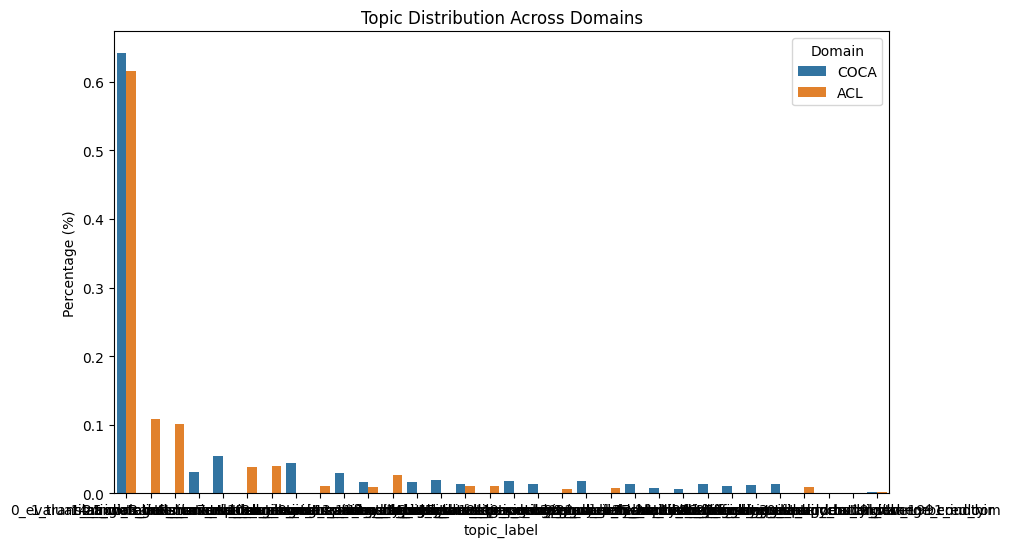

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Reshape the dataframe to long format
df_melted = topic_comparison.melt(id_vars='topic_label', value_vars=['COCA', 'ACL'], 
                    var_name='Domain', value_name='Percentage')

# Create the plot with Seaborn
plt.figure(figsize=(10, 6))
sns.barplot(x='topic_label', y='Percentage', hue='Domain', data=df_melted)

# Add title and labels
plt.title('Topic Distribution Across Domains')
plt.ylabel('Percentage (%)')
plt.show()